# Part 2: Position Auctions — Truthful Mechanisms and Online Learning

This notebook implements:
- VCG (welfare-optimal, truthful) for separable position auctions
- Myerson revenue-optimal (oracle) using known distributions
- Myerson plug-in learner: empirical CDFs to approximate virtual values and learn the mechanism online
- Baseline (practice): GSP with quality scores (non-truthful)
- Extension: Amazon-style quality scores and per-slot dynamic reserves

We use expected clicks with position weights `w` (no Bernoulli sampling).


In [1]:
# Setup
import os
import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = "/Users/harashimakoshi/CS332/332Project4"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures", "part2")
RES_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
RNG = np.random.default_rng(7)


In [2]:
# Distributions and samplers (homogeneous by default)

def sample_uniform(n: int, rng: np.random.Generator) -> np.ndarray:
    return rng.random(n)

# Quadratic CDF F(z)=z^2 on [0,1], inverse CDF z = sqrt(q)

def sample_quadratic(n: int, rng: np.random.Generator) -> np.ndarray:
    return np.sqrt(rng.random(n))

SAMPLERS: Dict[str, Callable[[int, np.random.Generator], np.ndarray]] = {
    "uniform": sample_uniform,
    "quadratic": sample_quadratic,
}

# Virtual value (oracle) for known distributions

def phi_uniform(v: float) -> float:
    # F(v)=v, f(v)=1 => phi(v)=v-(1-F)/f = v-(1-v)=2v-1
    return 2.0 * v - 1.0

def phi_quadratic(v: float) -> float:
    # F(v)=v^2, f(v)=2v => phi(v)=v - (1-v^2)/(2v) = 1.5*v - 1/(2v)
    v = max(v, 1e-6)
    return 1.5 * v - 0.5 / v

PHI_ORACLE: Dict[str, Callable[[float], float]] = {
    "uniform": phi_uniform,
    "quadratic": phi_quadratic,
}


In [3]:
# Position weights and helpers

def normalize_w(w: np.ndarray) -> np.ndarray:
    # ensure non-increasing and non-negative
    w = np.asarray(w, dtype=float)
    w = np.maximum.accumulate(w[::-1])[::-1]  # make non-increasing by flooring to suffix max
    w[w < 0] = 0.0
    return w

@dataclass
class PositionEnv:
    m: int
    w: np.ndarray  # shape (m,)
    dist_name: str

    def sample_values(self, rng: np.random.Generator) -> np.ndarray:
        sampler = SAMPLERS[self.dist_name]
        return sampler(self.m, rng)



In [4]:
# VCG for separable position auctions (expected clicks model)
# Values are per-click values; welfare = sum_j w_j * v_(j) with v sorted descending.
# Payment per click for slot j: ppc_j = (sum_{t=j}^K (w_t - w_{t+1}) v_{(t+1)}) / w_j, with w_{K+1}=0.

from typing import NamedTuple

class Allocation(NamedTuple):
    order: np.ndarray  # indices of agents from slot 1..m
    revenue: float
    per_click_prices: np.ndarray  # length K, price per click charged to each allocated agent


def vcg_allocation(values: np.ndarray, w: np.ndarray) -> Allocation:
    m = len(values)
    K = min(len(w), m)
    w_used = w[:K]
    w_ext = np.concatenate([w_used, np.array([0.0])])
    # sort bidders by value desc
    order = np.argsort(values)[::-1]
    v_sorted = values[order]
    ppc = np.zeros(K, dtype=float)
    # compute VCG per-click prices
    for j in range(K):
        tail = 0.0
        for t in range(j, K):
            nxt = v_sorted[t+1] if (t+1) < m else 0.0
            tail += (w_ext[t] - w_ext[t+1]) * nxt
        ppc[j] = tail / max(w_used[j], 1e-12)
    total_rev = float(np.sum(w_used * ppc))
    return Allocation(order=order[:K], revenue=total_rev, per_click_prices=ppc)



In [5]:
# Myerson (oracle) allocation and revenue for known distributions
# We assume regularity and compute virtual values via PHI_ORACLE, allocate by phi, drop negative phi.

@dataclass
class MyersonResult:
    order: np.ndarray
    revenue: float
    phi_values: np.ndarray


def myerson_oracle(values: np.ndarray, w: np.ndarray, dist_name: str) -> MyersonResult:
    phi_fn = PHI_ORACLE[dist_name]
    phi = np.array([phi_fn(v) for v in values], dtype=float)
    # Only non-negative virtual values contribute to revenue
    order = np.argsort(phi)[::-1]
    phi_sorted = phi[order]
    K = min(len(w), len(values))
    w_used = w[:K]
    rev = float(np.sum(w_used * np.maximum(0.0, phi_sorted[:K])))
    return MyersonResult(order=order[:K], revenue=rev, phi_values=phi)


In [6]:
# Empirical CDF + smoothed density -> plug-in virtual values
# Simple binning density estimate with small additive smoothing; then phi_hat = v - (1-F_hat(v))/f_hat(v)

class ECDFDensity:
    def __init__(self, bins: int = 200, smoothing: float = 1e-3):
        self.bins = bins
        self.smoothing = smoothing
        self.edges = np.linspace(0.0, 1.0, bins + 1)
        self.counts = np.zeros(bins, dtype=float)
        self.n = 0

    def update(self, samples: np.ndarray) -> None:
        if samples.size == 0:
            return
        c, _ = np.histogram(np.clip(samples, 0.0, 1.0), bins=self.edges)
        self.counts += c
        self.n += int(samples.size)

    def F_hat(self, v: float) -> float:
        idx = np.searchsorted(self.edges, v, side="right") - 1
        idx = int(np.clip(idx, 0, self.bins - 1))
        cum = float(np.sum(self.counts[: idx + 1]))
        return cum / max(self.n, 1)

    def f_hat(self, v: float) -> float:
        idx = np.searchsorted(self.edges, v, side="right") - 1
        idx = int(np.clip(idx, 0, self.bins - 1))
        width = float(self.edges[idx + 1] - self.edges[idx])
        density = (self.counts[idx] + self.smoothing) / (max(self.n, 1) * max(width, 1e-12))
        return float(density)

    def phi_hat(self, v: float) -> float:
        Fv = self.F_hat(v)
        fv = max(self.f_hat(v), 1e-6)
        return float(v - (1.0 - Fv) / fv)


class PluginMyerson:
    def __init__(self, m: int, bins: int = 200):
        self.models = [ECDFDensity(bins=bins) for _ in range(m)]

    def update(self, values: np.ndarray) -> None:
        for i, v in enumerate(values):
            self.models[i].update(np.array([v]))

    def phi_values(self, values: np.ndarray) -> np.ndarray:
        return np.array([self.models[i].phi_hat(float(values[i])) for i in range(values.size)], dtype=float)


def myerson_plugin_round(values: np.ndarray, w: np.ndarray, learner: PluginMyerson) -> float:
    phi = learner.phi_values(values)
    order = np.argsort(phi)[::-1]
    K = min(len(w), len(values))
    w_used = w[:K]
    rev = float(np.sum(w_used * np.maximum(0.0, phi[order][:K])))
    learner.update(values)
    return rev


In [7]:
# GSP with quality scores (practice baseline, non-truthful)
# Rank by score s_i = q_i * b_i (we assume bids = values here to compare revenue levels)
# CPC for slot j: ppc_j = s_{j+1} / q_{j} (when defined), total payment = w_j * ppc_j

@dataclass
class QualityConfig:
    q: np.ndarray  # per-bidder quality scores in [0, +inf)


def gsp_revenue(values: np.ndarray, w: np.ndarray, qc: QualityConfig) -> float:
    m = len(values)
    q = qc.q
    scores = q * values
    order = np.argsort(scores)[::-1]
    s_sorted = scores[order]
    q_sorted = q[order]
    K = len(w)
    total = 0.0
    for j in range(K):
        next_score = s_sorted[j+1] if (j+1) < m else 0.0
        ppc = next_score / max(q_sorted[j], 1e-12)
        total += w[j] * ppc
    return float(total)


In [8]:
# EXTENSION: slot-specific dynamic reserves learned online (simple epsilon-greedy per slot)

@dataclass
class SlotReserveBanditCfg:
    grid_size: int = 51
    T: int = 20000
    c: float = 1.0  # epsilon schedule: min(1, c/sqrt(t))

class SlotBandit:
    def __init__(self, grid_size: int):
        self.grid = np.linspace(0.0, 1.0, grid_size)
        self.counts = np.zeros(grid_size, dtype=int)
        self.means = np.zeros(grid_size, dtype=float)
        self.t = 0

    def epsilon(self, c: float) -> float:
        return 1.0 if self.t <= 0 else min(1.0, c / math.sqrt(self.t))

    def select(self, c: float) -> int:
        self.t += 1
        if RNG.random() < self.epsilon(c):
            return int(RNG.integers(len(self.grid)))
        return int(np.argmax(self.means))

    def update(self, arm: int, reward: float) -> None:
        self.counts[arm] += 1
        n = self.counts[arm]
        self.means[arm] += (reward - self.means[arm]) / n


def reserves_filter(values: np.ndarray, reserves: np.ndarray, order: np.ndarray) -> np.ndarray:
    # Enforce per-slot reserve on value; zero out if below reserve for that slot
    K = reserves.size
    filtered = values.copy()
    for j in range(K):
        i = int(order[j])
        if filtered[i] < reserves[j]:
            filtered[i] = 0.0
    return filtered


def run_extension_round(values: np.ndarray, w: np.ndarray, q: np.ndarray, bandits: List[SlotBandit], c: float) -> Tuple[float, np.ndarray, np.ndarray]:
    # Rank by quality-weighted value (practice-like), then apply per-slot reserve, charge GSP prices
    scores = q * values
    order = np.argsort(scores)[::-1]
    K = len(w)
    reserves = np.zeros(K, dtype=float)
    slot_rewards_for_bandit = np.zeros(K, dtype=float)
    # choose per-slot reserves
    for j in range(K):
        arm = bandits[j].select(c)
        reserves[j] = bandits[j].grid[arm]
    # apply reserves on values (alternatively on scores)
    eff_values = reserves_filter(values, reserves, order)
    # compute GSP revenue with quality using filtered values
    rev = gsp_revenue(eff_values, w, QualityConfig(q=q))
    # credit slot rewards roughly proportional to their contribution (approx: w_j * price-per-click)
    # recompute CPC components to apportion reward by slot
    m = len(values)
    s_sorted = (q * eff_values)[order]
    q_sorted = q[order]
    for j in range(K):
        next_score = s_sorted[j+1] if (j+1) < m else 0.0
        ppc = next_score / max(q_sorted[j], 1e-12)
        slot_rewards_for_bandit[j] = w[j] * ppc
    return rev, slot_rewards_for_bandit, reserves


In [9]:
# Experiment harness

@dataclass
class ExpCfg:
    dist_name: str
    m: int
    w: np.ndarray
    T: int = 20000
    seeds: List[int] = None


def run_rounds(cfg: ExpCfg) -> Dict[str, np.ndarray]:
    if cfg.seeds is None:
        cfg.seeds = [1, 2, 3]
    m, T = cfg.m, cfg.T
    w = cfg.w

    # Myerson oracle revenue series
    oracle_series = np.zeros(T, dtype=float)
    # VCG revenue series
    vcg_series = np.zeros(T, dtype=float)
    # Plug-in learner revenue series
    plugin_series = np.zeros(T, dtype=float)

    learner = PluginMyerson(m=m, bins=200)
    rng = np.random.default_rng(2025)

    for t in range(T):
        values = SAMPLERS[cfg.dist_name](m, rng)
        # oracle
        oracle_series[t] = myerson_oracle(values, w, cfg.dist_name).revenue
        # vcg
        vcg_series[t] = vcg_allocation(values, w).revenue
        # plugin
        plugin_series[t] = myerson_plugin_round(values, w, learner)

    return {
        "oracle": oracle_series,
        "vcg": vcg_series,
        "plugin": plugin_series,
    }


def plot_revenue_ci(series: Dict[str, np.ndarray], title: str, save: Optional[str] = None, tight: bool = True, pad: float = 0.02):
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for name, s in series.items():
        avg = np.cumsum(s) / (np.arange(s.size) + 1)
        ax.plot(avg, label=name)
    if tight:
        vals = np.concatenate([np.cumsum(s) / (np.arange(s.size) + 1) for s in series.values()])
        y_lo, y_hi = float(np.min(vals)), float(np.max(vals))
        span = max(y_hi - y_lo, 1e-6)
        ax.set_ylim(y_lo - pad * span, y_hi + pad * span)
    ax.set_title(title)
    ax.set_xlabel("Round")
    ax.set_ylabel("Average revenue")
    ax.legend()
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150)
    plt.show()


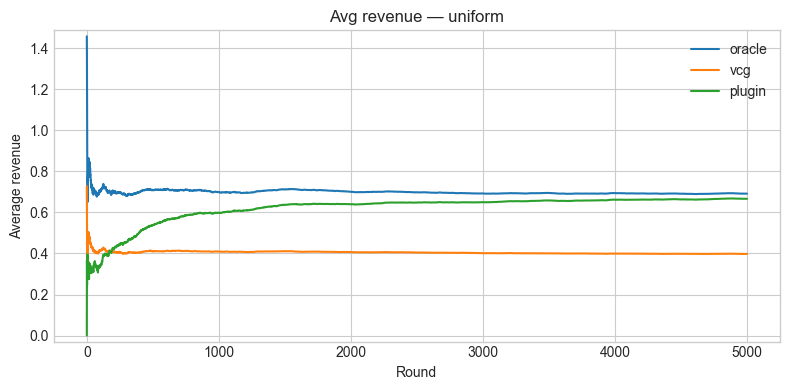

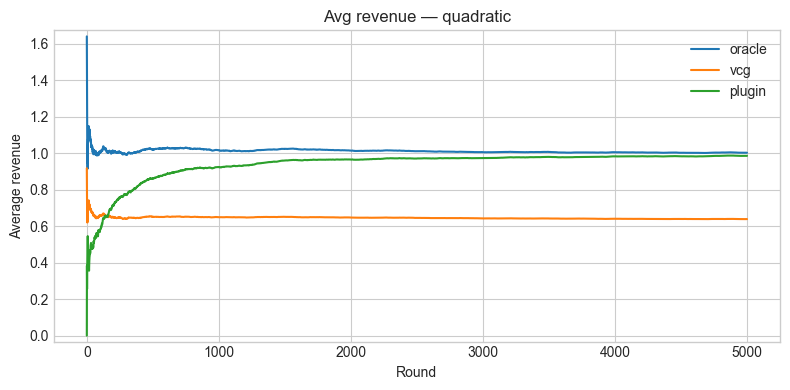

In [10]:
# Run example experiments and plot (small T first for speed)

w = normalize_w(np.array([0.8, 0.6, 0.4, 0.2]))
for dist in ["uniform", "quadratic"]:
    cfg = ExpCfg(dist_name=dist, m=4, w=w, T=5000)
    series = run_rounds(cfg)
    plot_revenue_ci(series, title=f"Avg revenue — {dist}", save=os.path.join(FIG_DIR, f"rev_{dist}.png"))


In [11]:
# Save a minimal summary CSV row for one config (extend as needed)
import csv

def export_summary_row(dist_name: str, m: int, w: np.ndarray, T: int = 20000):
    series = run_rounds(ExpCfg(dist_name=dist_name, m=m, w=w, T=T))
    row = {
        "distribution": dist_name,
        "m": m,
        "oracle_final_avg": float(np.mean(series["oracle"])),
        "vcg_final_avg": float(np.mean(series["vcg"])),
        "plugin_final_avg": float(np.mean(series["plugin"]))
    }
    out = os.path.join(RES_DIR, "part2_summary.csv")
    write_header = not os.path.exists(out)
    with open(out, "a", newline="") as f:
        wtr = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            wtr.writeheader()
        wtr.writerow(row)

# Example:
export_summary_row("uniform", m=4, w=w, T=5000)


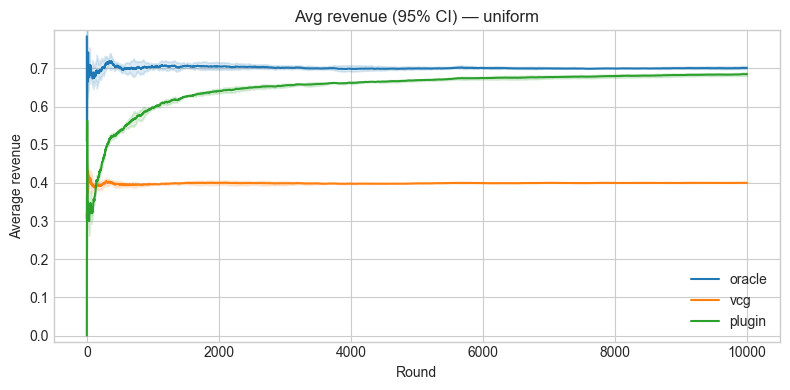

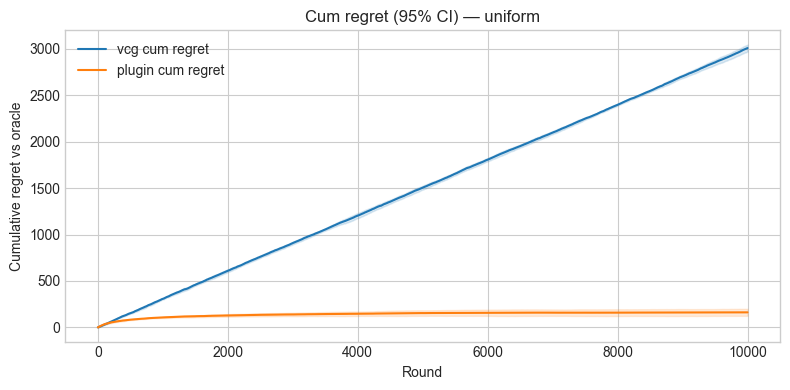

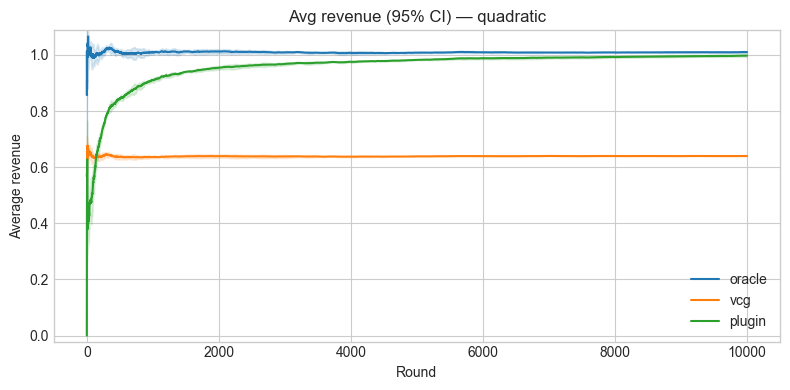

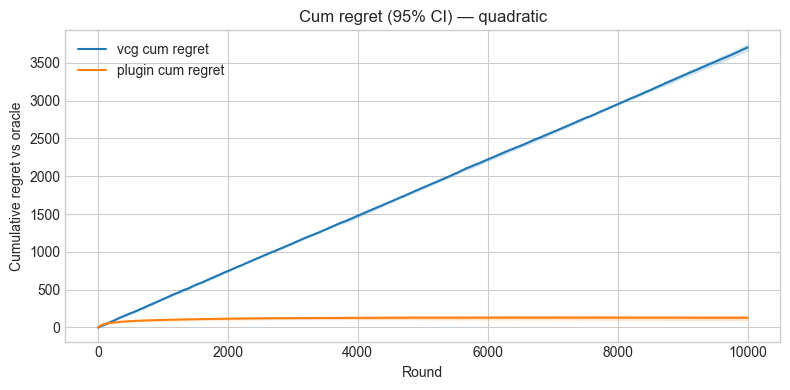

In [12]:
# Multi-seed CI and regret for Part 2

def run_rounds_multiseed(dist_name: str, m: int, w: np.ndarray, T: int, seeds: List[int]) -> Dict[str, np.ndarray]:
    S = len(seeds)
    oracle = np.zeros((S, T), dtype=float)
    vcg = np.zeros((S, T), dtype=float)
    plugin = np.zeros((S, T), dtype=float)
    for s_idx, s in enumerate(seeds):
        rng = np.random.default_rng(s)
        learner = PluginMyerson(m=m, bins=200)
        for t in range(T):
            values = SAMPLERS[dist_name](m, rng)
            oracle[s_idx, t] = myerson_oracle(values, w, dist_name).revenue
            vcg[s_idx, t] = vcg_allocation(values, w).revenue
            plugin[s_idx, t] = myerson_plugin_round(values, w, learner)
    return {"oracle": oracle, "vcg": vcg, "plugin": plugin}


def compute_ci(values_2d: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    mean = values_2d.mean(axis=0)
    std = values_2d.std(axis=0, ddof=1) if values_2d.shape[0] > 1 else np.zeros_like(mean)
    ci = 1.96 * std / max(1, np.sqrt(values_2d.shape[0]))
    return mean, mean - ci, mean + ci


def plot_ci_curves(series_multi: Dict[str, np.ndarray], title: str, save: Optional[str] = None, tight: bool = True, pad: float = 0.02):
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for name in ["oracle", "vcg", "plugin"]:
        s = series_multi[name]
        avg = np.cumsum(s, axis=1) / (np.arange(s.shape[1]) + 1)
        mean, lo, hi = compute_ci(avg)
        x = np.arange(avg.shape[1])
        line, = ax.plot(x, mean, label=name)
        ax.fill_between(x, lo, hi, color=line.get_color(), alpha=0.15)
    if tight:
        vals = np.concatenate([compute_ci(np.cumsum(series_multi[n], axis=1) / (np.arange(series_multi[n].shape[1]) + 1))[0] for n in series_multi])
        y_lo, y_hi = float(vals.min()), float(vals.max())
        span = max(y_hi - y_lo, 1e-6)
        ax.set_ylim(y_lo - pad * span, y_hi + pad * span)
    ax.set_title(title)
    ax.set_xlabel("Round")
    ax.set_ylabel("Average revenue")
    ax.legend()
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150)
    plt.show()


def plot_regret_ci(series_multi: Dict[str, np.ndarray], title: str, save: Optional[str] = None):
    oracle = series_multi["oracle"]
    out = {}
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for name in ["vcg", "plugin"]:
        s = series_multi[name]
        regret = np.cumsum(oracle - s, axis=1)
        mean, lo, hi = compute_ci(regret)
        x = np.arange(regret.shape[1])
        line, = ax.plot(x, mean, label=f"{name} cum regret")
        ax.fill_between(x, lo, hi, color=line.get_color(), alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Round")
    ax.set_ylabel("Cumulative regret vs oracle")
    ax.legend()
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150)
    plt.show()

# Example: CI/regret for uniform and quadratic at m=4, T=10000
for dist in ["uniform", "quadratic"]:
    multi = run_rounds_multiseed(dist, m=4, w=w, T=10000, seeds=[1,2,3])
    plot_ci_curves(multi, title=f"Avg revenue (95% CI) — {dist}", save=os.path.join(FIG_DIR, f"rev_{dist}_ci.png"))
    plot_regret_ci(multi, title=f"Cum regret (95% CI) — {dist}", save=os.path.join(FIG_DIR, f"regret_{dist}_ci.png"))


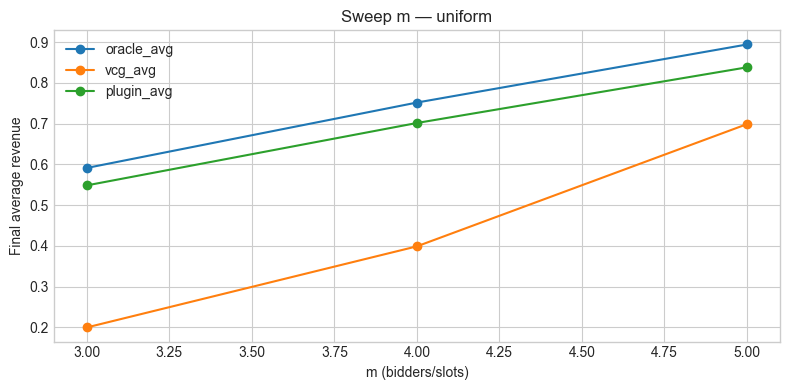

In [16]:
# Sweeps over m and w (final averages)

def sweep_m_w(dist_name: str, m_list: List[int], w_list: List[np.ndarray], T: int = 5000, seeds: List[int] = [1,2,3]) -> List[dict]:
    rows = []
    for m in m_list:
        for w in w_list:
            multi = run_rounds_multiseed(dist_name, m=m, w=w, T=T, seeds=seeds)
            row = {
                "dist": dist_name,
                "m": m,
                "w": ",".join(f"{x:.2f}" for x in w.tolist()),
                "oracle_avg": float(np.mean(multi["oracle"])),
                "vcg_avg": float(np.mean(multi["vcg"])),
                "plugin_avg": float(np.mean(multi["plugin"]))
            }
            rows.append(row)
    return rows


def plot_sweep_table(rows: List[dict], title: str, save: Optional[str] = None):
    # Simple bar-like line plot by m for each method (oracle/vcg/plugin), averaged across w_list
    import pandas as pd
    df = pd.DataFrame(rows)
    df_group = df.groupby(["dist", "m"])[["oracle_avg", "vcg_avg", "plugin_avg"]].mean().reset_index()
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for name in ["oracle_avg", "vcg_avg", "plugin_avg"]:
        ys = []
        xs = sorted(df_group["m"].unique())
        for m in xs:
            ys.append(float(df_group[(df_group["m"]==m)][name].values[0]))
        ax.plot(xs, ys, marker="o", label=name)
    ax.set_title(title)
    ax.set_xlabel("m (bidders/slots)")
    ax.set_ylabel("Final average revenue")
    ax.legend()
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150)
    plt.show()

# Example sweep:
w_base = [np.array([0.8,0.6,0.4,0.2]), np.array([0.9,0.7,0.5,0.3])]
rows = sweep_m_w("uniform", m_list=[3,4,5], w_list=w_base, T=3000, seeds=[1,2,3])
plot_sweep_table(rows, title="Sweep m — uniform", save=os.path.join(FIG_DIR, "sweep_m_uniform.png"))


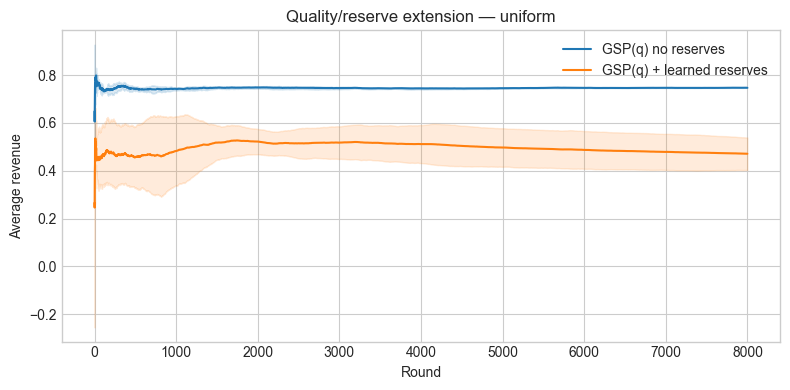

In [13]:
# Extension runner: quality scores with/without reserves

def run_quality_extension(dist_name: str, m: int, w: np.ndarray, q: np.ndarray, T: int = 10000, seeds: List[int] = [1,2,3]) -> Dict[str, np.ndarray]:
    S = len(seeds)
    rev_no_res = np.zeros((S, T), dtype=float)
    rev_reserves = np.zeros((S, T), dtype=float)
    reserves_traj = np.zeros((S, T, len(w)), dtype=float)
    for s_idx, s in enumerate(seeds):
        rng = np.random.default_rng(s)
        bandits = [SlotBandit(grid_size=51) for _ in range(len(w))]
        for t in range(T):
            values = SAMPLERS[dist_name](m, rng)
            # baseline no reserves (GSP with quality)
            rev_no_res[s_idx, t] = gsp_revenue(values, w, QualityConfig(q=q))
            # with learned reserves
            rev, slot_reward, reserves = run_extension_round(values, w, q, bandits, c=1.0)
            rev_reserves[s_idx, t] = rev
            reserves_traj[s_idx, t, :] = reserves
            # bandit updates per slot
            for j in range(len(w)):
                arm_idx = np.argmin(np.abs(bandits[j].grid - reserves[j]))
                bandits[j].update(arm_idx, slot_reward[j])
    return {"rev_no_res": rev_no_res, "rev_reserves": rev_reserves, "reserves": reserves_traj}


def plot_quality_extension(res: Dict[str, np.ndarray], title: str, save: Optional[str] = None):
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for name, label in [("rev_no_res", "GSP(q) no reserves"), ("rev_reserves", "GSP(q) + learned reserves")]:
        s = res[name]
        avg = np.cumsum(s, axis=1) / (np.arange(s.shape[1]) + 1)
        mean, lo, hi = compute_ci(avg)
        x = np.arange(avg.shape[1])
        line, = ax.plot(x, mean, label=label)
        ax.fill_between(x, lo, hi, color=line.get_color(), alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Round")
    ax.set_ylabel("Average revenue")
    ax.legend()
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150)
    plt.show()

# Example:
q = np.linspace(0.7, 1.2, len(w))  # simple quality gradient
ext = run_quality_extension("uniform", m=len(w), w=w, q=q, T=8000, seeds=[1,2,3])
plot_quality_extension(ext, title="Quality/reserve extension — uniform", save=os.path.join(FIG_DIR, "ext_quality_reserves.png"))


In [14]:
# Menu Auction with Exponentiated Gradient Algorithm for Price Learning

@dataclass
class EGPriceLearner:
    """
    Exponentiated Gradient Algorithmで各位置の価格ベクトルを学習するクラス
    
    各位置（スロット）ごとに、価格候補のベクトルをEGで学習:
    - 位置0（最低クリック率）: 価格候補のベクトルをEGで学習
    - 位置1: 価格候補のベクトルをEGで学習
    - ...
    - 位置m-1（最高クリック率）: 価格候補のベクトルをEGで学習
    """
    m: int
    grid_size: int = 51
    learning_rate: Optional[float] = None  # Noneなら自動計算: sqrt(log(k) / t)
    price_min: float = 0.0
    price_max: float = 1.0
    
    def __init__(self, m: int, grid_size: int = 51, learning_rate: Optional[float] = None,
                 price_min: float = 0.0, price_max: float = 1.0):
        self.m = m
        self.grid_size = grid_size
        self.learning_rate = learning_rate
        self.price_min = price_min
        self.price_max = price_max
        
        # m個のEGインスタンス（各位置用）
        self.egs = []
        for _ in range(m):
            eg = {
                'grid': np.linspace(price_min, price_max, grid_size),
                'weights': np.ones(grid_size) / grid_size,  # 初期重みは均等
                't': 0
            }
            self.egs.append(eg)
    
    def compute_prices(self, round_num: int) -> Tuple[np.ndarray, List[int], np.ndarray]:
        """
        現在のEGの重みに基づいて各位置の価格を選択
        
        Returns:
            prices: shape (m,) 各位置の価格（位置0が最低クリック率、位置m-1が最高クリック率）
            selected_indices: 各位置で選択されたグリッドのインデックス
            selected_prices: 選択された価格の値（selected_indicesと同じ）
        """
        prices = np.zeros(self.m, dtype=float)
        selected_indices = []
        selected_prices = []
        
        for j in range(self.m):
            eg = self.egs[j]
            
            # 重みに応じてアームをサンプリング
            weights = eg['weights']
            if np.sum(weights) <= 0 or not np.all(np.isfinite(weights)):
                # フォールバック：均等な重み
                weights = np.ones(self.grid_size) / self.grid_size
            
            idx = RNG.choice(len(weights), p=weights)
            selected_indices.append(idx)
            price = eg['grid'][idx]
            selected_prices.append(price)
            prices[j] = price
        
        return prices, selected_indices, np.array(selected_prices)
    
    def update(self, round_num: int, values: np.ndarray, w: np.ndarray, 
               selected_slots: List[int], prices: np.ndarray, selected_indices: List[int], 
               selected_prices: np.ndarray, rng: np.random.Generator):
        """
        Exponentiated Gradient Algorithmで各位置の価格ベクトルを更新
        Full-information setting: 全ての価格候補に対してシミュレーションを実行し、利潤を計算
        
        Args:
            round_num: ラウンド番号
            values: shape (m,) 各入札者の価値（Full-information）
            w: shape (m,) 各位置のクリック率（w[0]が最高、w[m-1]が最低）
            selected_slots: 選択された位置のインデックス
            prices: そのラウンドで提示された価格（shape (m,)）
            selected_indices: 各位置で選択されたグリッドのインデックス
            selected_prices: 選択された価格の値（shape (m,)）
            rng: 乱数生成器
        """
        # 学習率の計算（3倍に増やす）
        t = round_num + 1
        epsilon = self.learning_rate
        if epsilon is None:
            epsilon_multiplier = 3.0  # 学習率を3倍に
            epsilon = epsilon_multiplier * np.sqrt(np.log(self.grid_size) / max(t, 1))
        
        # 各位置jに対して更新
        for j in range(self.m):
            eg = self.egs[j]
            eg['t'] += 1
            
            # Full-information: 各アーム（価格候補）に報酬を割り当て
            # 全ての価格候補に対して、その価格が使われた場合の利潤をシミュレーションで計算
            alpha = np.zeros(self.grid_size, dtype=float)
            
            # 各価格候補に対してシミュレーションを実行
            for idx, price_candidate in enumerate(eg['grid']):
                # 位置jの価格をprice_candidateに置き換えた価格ベクトルを作成
                test_prices = prices.copy()
                test_prices[j] = price_candidate
                
                # その価格ベクトルでメニューオークションをシミュレーション
                revenue = simulate_menu_auction(values, w, test_prices, rng)
                alpha[idx] = revenue
            
            # Exponentiated Gradient更新: w_{t+1} ∝ w_t ⊙ exp(ε · α_t)
            # 数値安定性のため、報酬から最大値を引く
            alpha_shifted = alpha - np.max(alpha) if len(alpha) > 0 and np.max(alpha) > 0 else alpha
            unnorm = eg['weights'] * np.exp(epsilon * alpha_shifted)
            sum_unnorm = np.sum(unnorm)
            
            if np.isfinite(sum_unnorm) and sum_unnorm > 0:
                eg['weights'] = unnorm / sum_unnorm
            else:
                # 数値不安定な場合、均等な重みにリセット
                eg['weights'] = np.ones(self.grid_size) / self.grid_size


def simulate_menu_auction(values: np.ndarray, w: np.ndarray, prices: np.ndarray, 
                          rng: np.random.Generator) -> float:
    """
    メニューオークションをシミュレーションして利潤を計算
    
    Args:
        values: shape (m,) 各入札者の価値
        w: shape (m,) 各位置のクリック率（w[0]が最高、w[m-1]が最低）
        prices: shape (m,) 各位置の価格
        rng: 乱数生成器
    
    Returns:
        revenue: 利潤
    """
    m = len(values)
    
    # 入札者の順番をシャッフル
    bidder_order = np.arange(m)
    rng.shuffle(bidder_order)
    
    selected_slots = []
    available_slots = set(range(m))  # 利用可能なスロットの集合
    revenue = 0.0
    
    # 各入札者に対して順番にメニューを提示
    for bidder_idx in bidder_order:
        v_i = values[bidder_idx]
        
        # 利用可能なメニュー（位置、価格）の効用を計算
        # 位置j（j=0が最低クリック率、j=m-1が最高クリック率）の効用
        utilities = np.full(m, -np.inf, dtype=float)  # 利用不可なスロットは-inf
        for j in available_slots:
            # wはw[0]が最高クリック率なので、位置jのクリック率はw[m-1-j]
            click_rate = w[m - 1 - j]
            utilities[j] = click_rate * v_i - prices[j]
        
        # 最大効用のメニューを選択（全て負または-infなら選択しない）
        max_utility = np.max(utilities)
        if max_utility >= 0:
            selected_slot = int(np.argmax(utilities))
            selected_slots.append(selected_slot)
            revenue += prices[selected_slot]
            # 選択されたスロットを利用可能な集合から除外
            available_slots.remove(selected_slot)
    
    return revenue


def run_menu_auction_round(values: np.ndarray, w: np.ndarray, learner: EGPriceLearner, 
                           round_num: int, rng: np.random.Generator) -> Tuple[float, List[int], np.ndarray]:
    """
    メニューオークションの1ラウンドを実行
    
    Args:
        values: shape (m,) 各入札者の価値
        w: shape (m,) 各位置のクリック率（w[0]が最高、w[m-1]が最低）
        learner: EGPriceLearner
        round_num: ラウンド番号
        rng: 乱数生成器
    
    Returns:
        revenue: 利潤
        selected_slots: 選択された位置のインデックス
        prices: 提示された価格
    """
    m = len(values)
    
    # 価格を計算
    prices, selected_indices, selected_prices = learner.compute_prices(round_num)
    
    # 入札者の順番をシャッフル
    bidder_order = np.arange(m)
    rng.shuffle(bidder_order)
    
    selected_slots = []
    available_slots = set(range(m))  # 利用可能なスロットの集合
    revenue = 0.0
    
    # 各入札者に対して順番にメニューを提示
    for bidder_idx in bidder_order:
        v_i = values[bidder_idx]
        
        # 利用可能なメニュー（位置、価格）の効用を計算
        # 位置j（j=0が最低クリック率、j=m-1が最高クリック率）の効用
        utilities = np.full(m, -np.inf, dtype=float)  # 利用不可なスロットは-inf
        for j in available_slots:
            # wはw[0]が最高クリック率なので、位置jのクリック率はw[m-1-j]
            click_rate = w[m - 1 - j]
            utilities[j] = click_rate * v_i - prices[j]
        
        # 最大効用のメニューを選択（全て負または-infなら選択しない）
        max_utility = np.max(utilities)
        if max_utility >= 0:
            selected_slot = int(np.argmax(utilities))
            selected_slots.append(selected_slot)
            revenue += prices[selected_slot]
            # 選択されたスロットを利用可能な集合から除外
            available_slots.remove(selected_slot)
    
    # EGを更新（各位置の価格ベクトルを更新）
    # Full-information setting: 全ての価格候補に対してシミュレーションを実行
    learner.update(round_num, values, w, selected_slots, prices, selected_indices, selected_prices, rng)
    
    return revenue, selected_slots, prices


In [16]:
# Experiment harness for Menu Auction with EG

def run_menu_auction_multiseed(dist_name: str, m: int, w: np.ndarray, T: int, 
                                seeds: List[int], grid_size: int = 51) -> Dict[str, np.ndarray]:
    """
    Menu Auction with EGを複数のシードで実行
    
    Returns:
        Dict with keys:
        - "menu_eg": shape (S, T) 各シード、各ラウンドの利潤
    """
    S = len(seeds)
    menu_eg = np.zeros((S, T), dtype=float)
    
    for s_idx, s in enumerate(seeds):
        rng = np.random.default_rng(s)
        learner = EGPriceLearner(m=m, grid_size=grid_size)
        
        for t in range(T):
            values = SAMPLERS[dist_name](m, rng)
            revenue, _, _ = run_menu_auction_round(values, w, learner, t, rng)
            menu_eg[s_idx, t] = revenue
    
    return {"menu_eg": menu_eg}


def run_rounds_with_menu_auction(dist_name: str, m: int, w: np.ndarray, T: int, 
                                  seeds: List[int] = [1, 2, 3]) -> Dict[str, np.ndarray]:
    """
    既存のメソッド（oracle, vcg, plugin）とMenu Auction with EGを一緒に実行
    """
    # 既存のメソッド
    existing = run_rounds_multiseed(dist_name, m, w, T, seeds)
    
    # Menu Auction with EG
    menu_result = run_menu_auction_multiseed(dist_name, m, w, T, seeds)
    
    # 統合
    result = {
        "oracle": existing["oracle"],
        "vcg": existing["vcg"],
        "plugin": existing["plugin"],
        "menu_eg": menu_result["menu_eg"]
    }
    
    return result


In [17]:
# Plotting functions for Menu Auction with EG

def plot_ci_curves_with_menu(series_multi: Dict[str, np.ndarray], title: str, 
                               save: Optional[str] = None, tight: bool = True, pad: float = 0.02):
    """
    Menu Auction with EGを含む可視化
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for name in ["oracle", "vcg", "plugin", "menu_eg"]:
        if name not in series_multi:
            continue
        s = series_multi[name]
        avg = np.cumsum(s, axis=1) / (np.arange(s.shape[1]) + 1)
        mean, lo, hi = compute_ci(avg)
        x = np.arange(avg.shape[1])
        label_map = {
            "oracle": "Myerson Oracle",
            "vcg": "VCG",
            "plugin": "Plugin Myerson",
            "menu_eg": "Menu Auction (EG)"
        }
        line, = ax.plot(x, mean, label=label_map.get(name, name))
        ax.fill_between(x, lo, hi, color=line.get_color(), alpha=0.15)
    if tight:
        vals = np.concatenate([compute_ci(np.cumsum(series_multi[n], axis=1) / (np.arange(series_multi[n].shape[1]) + 1))[0] 
                               for n in series_multi])
        y_lo, y_hi = float(vals.min()), float(vals.max())
        span = max(y_hi - y_lo, 1e-6)
        ax.set_ylim(y_lo - pad * span, y_hi + pad * span)
    ax.set_title(title)
    ax.set_xlabel("Round")
    ax.set_ylabel("Average revenue")
    ax.legend()
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150)
    plt.show()


def plot_regret_ci_with_menu(series_multi: Dict[str, np.ndarray], title: str, 
                              save: Optional[str] = None):
    """
    Menu Auction with EGを含むregret可視化
    """
    oracle = series_multi["oracle"]
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for name in ["vcg", "plugin", "menu_eg"]:
        if name not in series_multi:
            continue
        s = series_multi[name]
        regret = np.cumsum(oracle - s, axis=1)
        mean, lo, hi = compute_ci(regret)
        x = np.arange(regret.shape[1])
        label_map = {
            "vcg": "VCG cum regret",
            "plugin": "Plugin Myerson cum regret",
            "menu_eg": "Menu Auction (EG) cum regret"
        }
        line, = ax.plot(x, mean, label=label_map.get(name, f"{name} cum regret"))
        ax.fill_between(x, lo, hi, color=line.get_color(), alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Round")
    ax.set_ylabel("Cumulative regret vs oracle")
    ax.legend()
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150)
    plt.show()


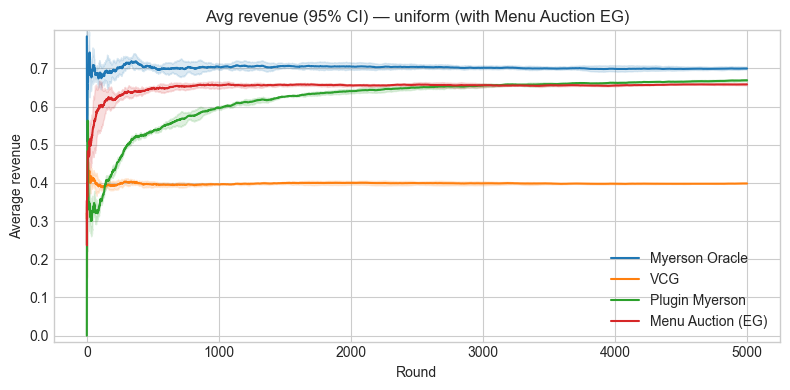

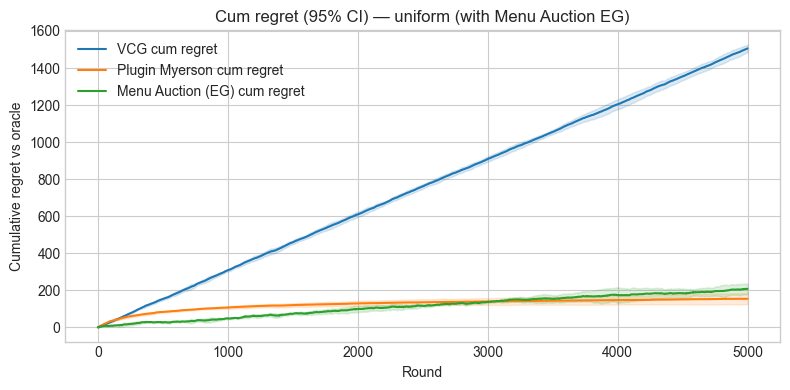

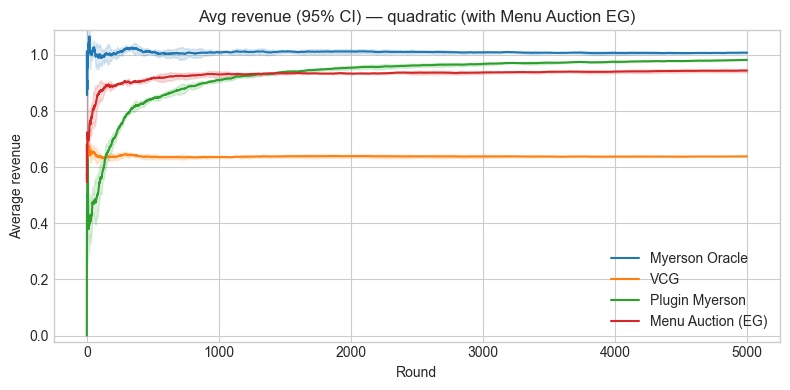

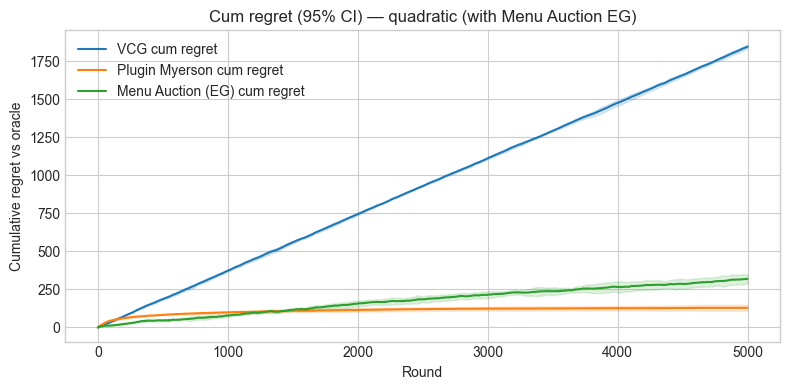

In [18]:
# Run Menu Auction with EG experiments

w = normalize_w(np.array([0.8, 0.6, 0.4, 0.2]))

# Example: uniform distribution
for dist in ["uniform", "quadratic"]:
    multi = run_rounds_with_menu_auction(dist, m=4, w=w, T=5000, seeds=[1, 2, 3])
    plot_ci_curves_with_menu(multi, title=f"Avg revenue (95% CI) — {dist} (with Menu Auction EG)", 
                            save=os.path.join(FIG_DIR, f"rev_{dist}_menu_eg_ci.png"))
    plot_regret_ci_with_menu(multi, title=f"Cum regret (95% CI) — {dist} (with Menu Auction EG)", 
                            save=os.path.join(FIG_DIR, f"regret_{dist}_menu_eg_ci.png"))


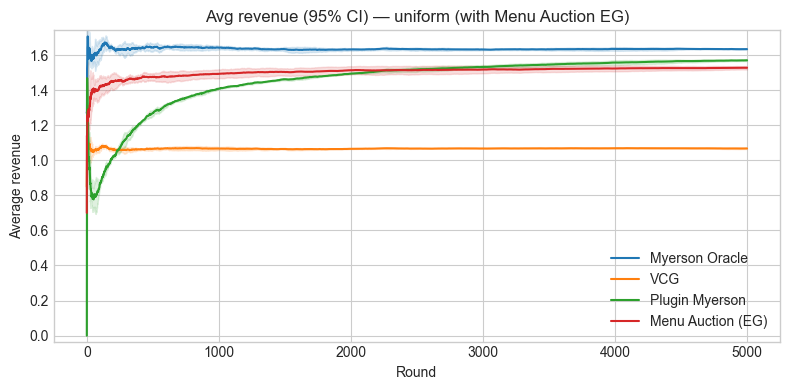

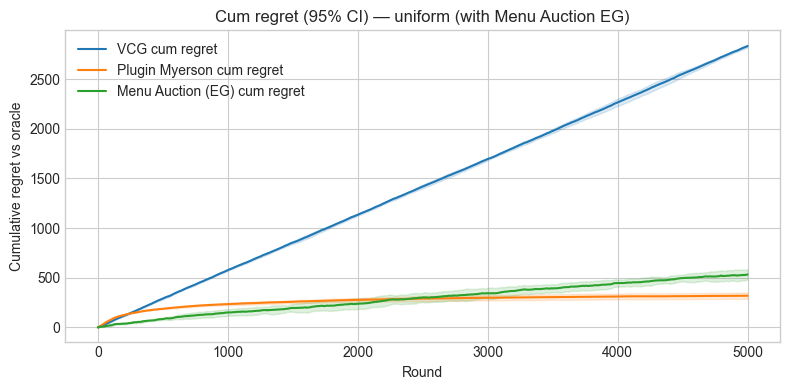

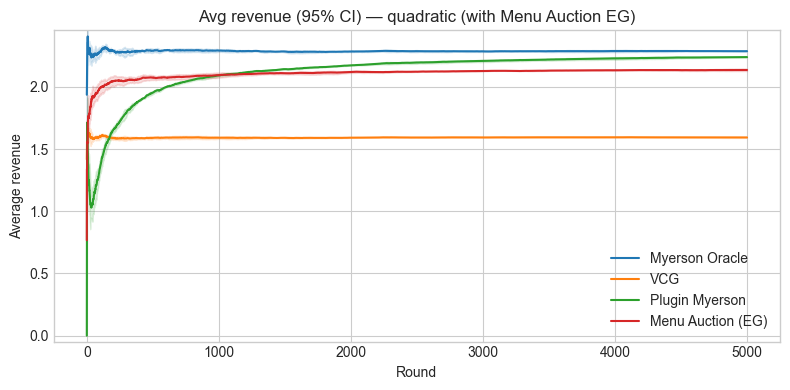

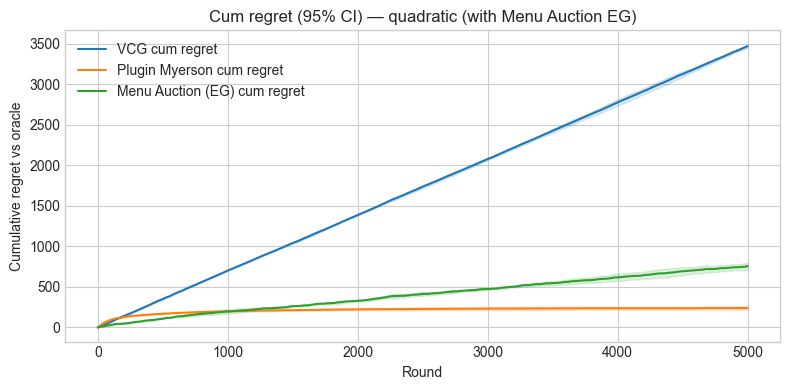

In [23]:
# Example: uniform distribution with m=10
w = normalize_w(np.array([0.8, 0.7, 0.6, 0.5, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15]))
for dist in ["uniform", "quadratic"]:
    multi = run_rounds_with_menu_auction(dist, m=10, w=w, T=5000, seeds=[1, 2, 3])
    plot_ci_curves_with_menu(multi, title=f"Avg revenue (95% CI) — {dist} (with Menu Auction EG)", 
                            save=os.path.join(FIG_DIR, f"rev_{dist}_menu_eg_ci_large_m.png"))
    plot_regret_ci_with_menu(multi, title=f"Cum regret (95% CI) — {dist} (with Menu Auction EG)", 
                            save=os.path.join(FIG_DIR, f"regret_{dist}_menu_eg_ci_large_m.png"))
